In [1]:
# import ipympl
# %matplotlib ipympl

In [8]:
import os
# os.environ["HYRIVER_CACHE_NAME"] = "../data/hyriver.sqlite"
# os.environ['REQUESTS_CA_BUNDLE'] = "/Library/Application Support/Netskope/STAgent/data/nscacert.pem"
# os.environ['SSL_CERT_DIR'] = "/Library/Application Support/Netskope/STAgent/data"
# os.environ['SSL_CERT_FILE'] = "/Library/Application Support/Netskope/STAgent/data/nscacert.pem"

import pynhd
import pandas as pd
import geopandas as gpd
import numpy as np
from matplotlib import pyplot as plt

version = '_v21' # raw NHD Medium Res
#version = '_v22' # with Blodgett cleanup
#version = '_v23' # with Blodgett cleanup and purge_dendritic

In [9]:
nldi = pynhd.NLDI()
wbd = pynhd.WaterData('wbd04')
nhd = pynhd.WaterData('nhdflowline_network')
catch = pynhd.WaterData('catchmentsp')

nhd_wb = pynhd.WaterData('nhdwaterbody')

In [83]:
# download the HUC
huc = wbd.byid('huc4', ['1204',])
bounds = huc.geometry[0].bounds
print(bounds)
print(huc.geometry[0].bounds)
print(huc)


(-95.98792, 28.843289, -93.645562, 30.773863)
(-95.98792, 28.843289, -93.645562, 30.773863)
                                            geometry  objectid  \
0  MULTIPOLYGON (((-95.75142 30.77226, -95.75133 ...       173   

                                    tnmid metasourceid sourcedatadesc  \
0  {A4FF4D45-5C68-4892-B2FE-4E1B2C67524A}         None           None   

  sourceoriginator sourcefeatureid              loaddate gnis_id   areaacres  \
0             None            None  2016-08-25T05:17:45Z    None  5320654.57   

   areasqkm states  huc4                       name  \
0  21531.94  LA,TX  1204  Galveston Bay-San Jacinto   

                                 globalid  
0  {2BDEA252-542D-49E2-8082-D0DB63072DB6}  


<Axes: >

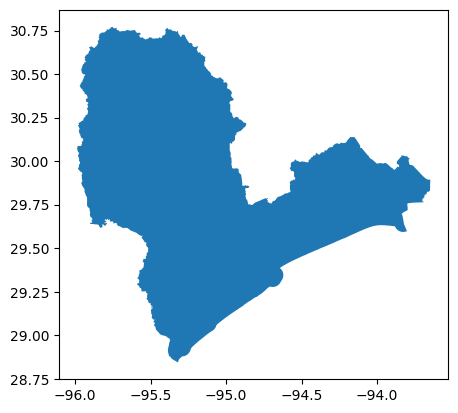

In [84]:
huc.geometry.plot()

In [85]:
# download reaches and filter to the huc
reaches = nhd.bybox(huc.geometry[0].bounds)
reaches = reaches[reaches.intersects(huc.geometry[0])]

In [86]:
# clean up reaches
if version == '_v21':
    reaches2 = reaches

elif version == '_v22':
    reaches2 = pynhd.prepare_nhdplus(reaches, 0, 0, 
                                    purge_non_dendritic=False,
                                    use_enhd_attrs=True)  
elif version == '_v23':
    reaches2 = pynhd.prepare_nhdplus(reaches, 0, 0, 
                                    purge_non_dendritic=True,
                                    use_enhd_attrs=True)


In [87]:
waterbodies = nhd_wb.bybox(huc.geometry[0].bounds)
waterbodies = waterbodies[waterbodies.intersects(huc.geometry[0])]

# limit to those > 1 km^2
waterbodies = waterbodies[waterbodies.areasqkm > 1]

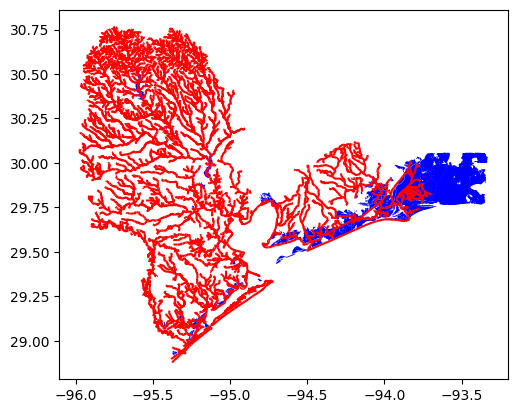

In [88]:
ax = waterbodies.plot(color='b')
reaches2.plot(color='r', ax=ax)
plt.show()



In [89]:
# download the catchments for each reach
comids = list(reaches.comid)
cas_raw = [catch.byid('featureid', comids[1000*i:1000*(i+1)]) for i in range(0,(len(reaches)//1000)+1)]
cas = gpd.GeoDataFrame(pd.concat(cas_raw), crs=reaches.crs)

/var/folders/pp/3_4s1nfd6w16js1fxnps88r4trd8l4/T/ipykernel_40794/2518788439.py:3: UserWarning: 8 of 1000 requests failed.. IDs of the failed requests are ['1466440', '1440621', '1439315', '1440415', '1440607', '1440419', '1440617', '1143316']
  cas_raw = [catch.byid('featureid', comids[1000*i:1000*(i+1)]) for i in range(0,(len(reaches)//1000)+1)]
/var/folders/pp/3_4s1nfd6w16js1fxnps88r4trd8l4/T/ipykernel_40794/2518788439.py:3: UserWarning: 34 of 1000 requests failed.. IDs of the failed requests are ['1475679', '1468408', '1479777', '1479769', '1468476', '1475699', '1468414', '1475677', '1479831', '1477175', '1479359', '1479863', '1475703', '1477187', '1475649', '1479439', '1475661', '1479905', '1479375', '1476943', '1479451', '1508303', '1475671', '1507979', '1476967', '1479907', '1477525', '1479705', '1479899', '1475685', '1479801', '1479737', '1475205', '1477569']
  cas_raw = [catch.byid('featureid', comids[1000*i:1000*(i+1)]) for i in range(0,(len(reaches)//1000)+1)]
/var/folders/pp

In [17]:
# write these to disk
huc.to_file(f'../data/nhd_mr_v2_huc1204.gpkg')
reaches['comid'] = reaches.comid.astype(str)
reaches.to_file(f'../data/nhd_mr_v2_huc1204_flowlines{version}.gpkg')
#reaches.to_file(f'../data/nhd_mr_v2_huc1402_flowlines{version}.shp')

cas['comid'] = cas.featureid.astype(str)
cas.to_file(f'../data/nhd_mr_v2_huc1204_catchments{version}.gpkg')


In [52]:
with open("../pickle_files/crs", 'rb') as handle:
    crs = pickle.load(handle)

In [64]:
shapefile_gages= '/Users/7s2/Research/projects/setx/SETx/data/gis/gagesII_9322_point_shapefile/gagesII_9322_sept30_2011.shp'
gages = gpd.read_file(shapefile_gages)
gages = gages.to_crs(crs)

In [61]:
neches_wb = huc.geometry.to_crs(crs)[0]

In [68]:
neches_gages = [point for point in gages.geometry if neches_wb.contains(point)]
neches_gages

[<POINT (401440.816 -1074785.461)>,
 <POINT (419846.641 -1118787.001)>,
 <POINT (446151.354 -1151104.649)>,
 <POINT (481919.683 -1197220.423)>,
 <POINT (456212.46 -1197968.011)>,
 <POINT (520762.401 -1206392.933)>,
 <POINT (475816.717 -1118991.329)>,
 <POINT (444103.682 -1108335.159)>,
 <POINT (464792.088 -1140246.777)>,
 <POINT (487460.007 -1161777.749)>,
 <POINT (494205.736 -1144172.721)>,
 <POINT (526058.258 -1154160.162)>,
 <POINT (541014.85 -1164810.858)>,
 <POINT (545596.415 -1230036.079)>,
 <POINT (554310.614 -1276642.852)>,
 <POINT (538041.947 -1273196.591)>,
 <POINT (533529.081 -1305208.28)>,
 <POINT (546692.224 -1296394.951)>,
 <POINT (553851.978 -1298276.22)>]

In [71]:
neches_gage_properties=[]
neches_gages = [point for point in gages.geometry if neches_wb.contains(point)]
for neches_gage in neches_gages: 
    gage = gages.loc[gages['geometry'].within(neches_gage)]

    gage_property_names = gages.columns.to_list()[:-1]
    gage_properties = gage.drop(['geometry'], axis=1)
    prop_dict = {name: value for name, value in zip(gage_property_names, gage_properties.values[0])}
    neches_gage_properties.append(prop_dict)

In [75]:
station_ids = [p['STAID'] for p in neches_gage_properties]

In [77]:
# load the observations file, and download the sites to get their geometry.  
# Note, we could construct this directly as the csv file has the lat/long but its easier to just go find them
# obs = pd.read_excel('../data-raw/outlet_ids.xlsx')
sites = nldi.getfeature_byid('nwissite', fids=[f'USGS-{str(stid).zfill(8)}' for stid in station_ids])

In [79]:
# query for all reaches within 1km of the site
site_reaches = [nldi.navigate_byid(fsource="nwissite", fid=f"USGS-{str(stid).zfill(8)}",
                                   navigation="upstreamTributaries", source="flowlines",
                                   distance=1) for stid in station_ids]

In [80]:
# sometimes this returns more than one reach for a given site -- find the closest
sites_mapped = sites.to_crs('5070')
for i, site_r in enumerate(site_reaches):
    if len(site_r) > 1:
        j = np.argmin(site_r.to_crs('5070').distance(sites_mapped.geometry[i]))
        site_reaches[i] = site_r[site_r.index == j]
site_reaches = pd.concat(site_reaches)
site_reaches.reset_index(inplace=True, drop=True)

In [81]:
# set the comid of the nearest reach for each station
sites['comid'] = site_reaches['nhdplus_comid'].astype(str)


In [82]:
# write the sites to file
sites.to_file(f'../data/neches_site_descriptions{version}.gpkg')